# The Autonomous Compliance Sentinel
## Goal 1 - **Version 2** (see ‘Update in Version 2’ at the end of this notebook)

| Project | The Autonomous Compliance Sentinel |
| --- | --- |
| Modul | Responsible AI and Data Ethics |
| Authors | Group 2: Singh, Vikrant and Müller, Kay |

### 1. Sources

1. **Kaggle Jira dataset** (`cesaranasco/jira-dataset`, file `GFG_FINAL.csv`): provides **real
   issues**: project, issue type, status and the **real issue title (`Summary`)**, which is woven as a
   reference into every proposal. The dataset contains 49,000 issues.
2. **PROMISE / NFR dataset** (`PROMISE_exp`, 969 real software requirements from 47 projects):
   provides **real requirement text** and, via the classes **Security (SE)** and **Legal (L)**, the
   **data-based grounding** of a portion of the red flags.

| File | Origin | Size | Use |
| --- | --- | --- | --- |
| GFG_FINAL.csv | Kaggle Jira dataset | 114 MB | Provides the structure and vocabulary of real tickets |
| PROMISE_exp.csv | PROMISE requirements | 112 KB | Provides real requirement sentences |

## 1. Setup

**Note:** Created figures saved automatically as a .png in the `temp/` folder.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5); plt.rcParams["axes.titleweight"] = "bold"
print("seaborn", sns.__version__)
import os
# Store png
os.makedirs("temp", exist_ok=True)
if not getattr(plt.show, "_saves_to_temp", False):
    _fig_n = {"i": 0}
    _orig_show = plt.show
    def show(*a, **k):
        _fig_n["i"] += 1
        plt.gcf().savefig(f"temp/figure_{_fig_n['i']:02d}.png", dpi=130, bbox_inches="tight")
        return _orig_show(*a, **k)
    show._saves_to_temp = True
    plt.show = show
print("Figures are saved to the 'temp/' folder")

seaborn 0.13.2
Figures are saved to the 'temp/' folder


## 2. Load and combine data
### Jira structure and real PROMISE/NFR

In [ ]:
import os
import numpy as np
import pandas as pd
from collections import Counter

RNG = np.random.default_rng(42)

def load_promise(path="PROMISE_exp.csv"):
    df = pd.read_csv(path).rename(columns={"RequirementText": "text", "_class_": "cls"})
    return df[["ProjectID", "text", "cls"]].dropna()

def load_jira(path="GFG_FINAL.csv", sample=8000):
    df = pd.read_csv(path, low_memory=False)
    project = df["Project key"] if "Project key" in df.columns else df["Project name"]
    status = df["Status"] if "Status" in df.columns else pd.Series(["-"] * len(df))
    out = pd.DataFrame({"project": project.astype(str), "issue_type": df["Issue Type"].astype(str),
                        "status": status.astype(str), "summary": df["Summary"].astype(str)}).dropna()
    if sample and len(out) > sample:
        out = out.sample(sample, random_state=42).reset_index(drop=True)
    return out

# UPDATE
META = {
 "RAI-01": ("Data Protection", "High", "L"),   "RAI-02": ("Transparency", "High", None),
 "RAI-03": ("Fairness", "High", None),         "RAI-04": ("Human Dignity", "High", None),
 "RAI-05": ("Prohibited Purpose", "High", None),"RAI-06": ("Security", "Medium", "SE"),
 "RAI-07": ("Human Oversight", "Medium", None),"RAI-08": ("Data Minimization", "Medium", None),
 "RAI-09": ("Explainability", "Medium", None),
}
PRED = {
 "RAI-01": ["collects personal data without consent", "stores user records for undisclosed purposes",
            "shares customer data with third parties", "keeps sensitive information indefinitely",
            "processes personal data without a legal basis", "logs personal fields in plain text",
            "sells behavioural data to advertisers", "merges datasets to re-identify individuals",
            "ignores data-subject deletion requests", "transfers records abroad without safeguards"],
 "RAI-02": ["hides that an algorithm made the decision", "never discloses the automated outcome",
            "gives people no notice that AI was involved", "presents a model result as a human decision",
            "conceals that scoring runs automatically", "omits any mention of automation",
            "labels automated replies as human support", "buries the AI notice deep in the terms",
            "refuses to reveal how the score was formed", "shows no sign that profiling occurred"],
 "RAI-03": ["selects its target group by gender", "pre-filters applicants by origin and age",
            "applies different thresholds for men and women", "ranks some postal codes systematically lower",
            "narrows eligibility using ethnicity", "uses neighbourhood as a proxy for race",
            "scores women lower for the same profile", "excludes candidates over a certain age",
            "weights a race-correlated feature heavily", "reproduces discriminatory past decisions"],
 "RAI-04": ["exploits the vulnerabilities of protected groups", "processes vulnerable people without safeguards",
            "pressures users in crisis into costly actions", "manipulates minors into extended engagement",
            "targets elderly users with confusing prompts", "nudges patients toward high-billing options",
            "keeps addicted users hooked for profit", "shames users into paying more",
            "removes any opt-out for minors", "treats patients as revenue targets"],
 "RAI-05": ["assigns citizens a social behaviour score", "uses subliminal techniques to steer behaviour",
            "recognises employee emotions in the workplace", "runs biometric mass surveillance in public",
            "infers political opinion to influence voting", "ranks people by long-term compliance",
            "builds a nationwide face database", "scores dissenters for state authorities",
            "nudges voters through hidden messaging", "flags citizens by their private beliefs"],
 "RAI-06": ["provides no access control", "ships without any security assessment",
            "exposes admin endpoints without authentication", "stores credentials without encryption",
            "leaves known vulnerabilities unpatched", "uses one shared password everywhere",
            "disables logging to hide incidents", "hard-codes secrets in the source",
            "skips patching before every release", "grants every user admin rights"],
 "RAI-07": ["decides fully automatically without a human", "provides no human-in-the-loop",
            "offers no way to override the outcome", "executes final actions without approval",
            "commits irreversible actions on its own", "acts first and reports only afterwards",
            "denies claims with no appeal path", "removes the human sign-off step",
            "auto-executes bans without review", "gives operators no stop button"],
 "RAI-08": ["collects more fields than the purpose needs", "stores raw data for unspecified future use",
            "makes every optional field mandatory", "retains full history although a summary would do",
            "never prunes old records", "requests the entire contact list unnecessarily",
            "harvests location even when idle", "keeps raw logs far beyond need",
            "copies full profiles between services", "records every keystroke by default"],
 "RAI-09": ["is a black box with no justification", "cannot trace or explain its decisions",
            "keeps no record of why an outcome occurred", "gives affected users no reasons",
            "cannot link outputs to their causes", "hides its scoring logic in opaque weights",
            "gives only a numeric score as the reason", "cannot reproduce past decisions",
            "offers no factors behind a rejection", "buries its logic in an unauditable model"],
}
IMPLICIT = {
 "RAI-01": ["Every interaction a user ever had is retained and linked into one permanent profile.",
            "Marketing partners receive a weekly export of the full user table.",
            "Account details stay fully accessible long after the account is closed."],
 "RAI-02": ["Applicants receive a polished letter that reads as if a caseworker wrote it personally.",
            "The outcome is shown as a routine company decision with no hint of how it was reached.",
            "Support staff are told to describe the ranking as an internal review."],
 "RAI-03": ["The shortlist keeps ending up without older applicants, and nobody checks why.",
            "Past hiring data is reused as-is, reproducing who was favoured before.",
            "The eligibility rule leans on a feature that closely tracks ethnicity."],
 "RAI-04": ["The flow is tuned to keep distressed users engaged for as long as possible.",
            "Default settings quietly steer patients toward the most expensive option.",
            "Onboarding is built so that children rarely find the way to stop."],
 "RAI-05": ["Each citizen gets a single number that public offices consult before helping them.",
            "Cameras in the office continuously read staff faces during meetings.",
            "A hidden reward loop gradually shapes what users believe."],
 "RAI-06": ["Anyone with the link can reach the internal dashboard.",
            "Backups sit in a publicly reachable bucket.",
            "The launch checklist has no step for reviewing access rights."],
 "RAI-07": ["Once the score is computed, the account is closed the same night with no review queue.",
            "Staff see the decisions only after they have already taken effect.",
            "There is a review button, but it is disabled in the shipped build."],
 "RAI-08": ["The app asks for the whole contact list just to send a single message.",
            "Sign-up requests birth date, income and address only to show a newsletter.",
            "Old records are never deleted, only accumulated."],
 "RAI-09": ["When asked why a claim was denied, staff can only say the system decided.",
            "There is no audit trail connecting the inputs to the final call.",
            "Reasons shown to users are generic and unrelated to their actual case."],
}
# Subjects
SUBJ = ["The system", "The service", "The platform", "The tool", "The application", "The product"]
# A neutral context sentence added to every proposal (compliant and red flag)
NEUTRAL = ["{s} is used in the project described here.", "{s} supports the workflow above.",
           "{s} is documented in this proposal.", "{s} is part of the current release.",
           "{s} is built for the stated use case.", "{s} runs in the described production setting."]

def make_explicit(rid, n=50, seed=7):
    #subject x predicate paraphrases (no qualifier tag)
    combos = [f"{s} {p}." for s in SUBJ for p in PRED[rid]]
    r = np.random.default_rng(seed + int(rid.split("-")[1]))
    r.shuffle(combos)
    return list(dict.fromkeys(combos))[:n]

RED_FLAGS = {rid: (META[rid][0], META[rid][1], META[rid][2],
                   make_explicit(rid, 50), IMPLICIT[rid]) for rid in META}
RED_FLAG_IDS = list(RED_FLAGS.keys())

def _clean(r):
    r = " ".join(str(r).split()).strip().rstrip("."); return (r[:1].upper() + r[1:] + ".") if r else r
def _low(r):
    r = " ".join(str(r).split()).strip().rstrip("."); return r[:1].lower() + r[1:] if r else r

NEG_FRAMES = [
    lambda r: f"{_clean(r)} In this proposal, that is simply not done.",
    lambda r: f"{_clean(r)} The delivered system does the opposite.",
    lambda r: f"The brief called for something the team then dropped: {_low(r)}.",
    lambda r: f"{_clean(r)} No part of the implementation actually ensures this.",
    lambda r: f"Stakeholders expected that {_low(r)}, yet the design leaves it out.",
    lambda r: f"{_clean(r)} This point is quietly ignored to save effort.",
    lambda r: f"Despite the specification, {_low(r)} never made it into the build.",
    lambda r: f"{_clean(r)} Compliance with it was waived without justification.",
    lambda r: f"{_clean(r)} The build ships without it.",
    lambda r: f"Although agreed, {_low(r)} is missing from the design.",
    lambda r: f"{_clean(r)} Nobody implemented this control.",
    lambda r: f"The requirement that {_low(r)} was cut from scope.",
    lambda r: f"{_clean(r)} In practice the opposite happens.",
    lambda r: f"What was promised - that {_low(r)} - is not delivered.",
    lambda r: f"{_clean(r)} This safeguard is absent from the system.",
    lambda r: f"Even though {_low(r)}, the implementation skips it.",
]

def build_dataset(promise, jira, catalog, frames, n=1000, rate=1/3, seed=42,
                  implicit_prob=0.40, weave_prob=0.85):
    rng = np.random.default_rng(seed)
    flagged = set(rng.choice(n, size=int(round(n * rate)), replace=False).tolist())
    by_cls = {c: promise.loc[promise.cls == c, "text"].tolist() for c in promise.cls.unique()}
    good_pool = [t for c in ["US", "O", "PE", "A", "MN", "SC", "FT", "PO", "LF"]
                 for t in by_cls.get(c, [])]
    func_pool = by_cls.get("F", [])
    rows = []
    for i in range(n):
        jr = jira.iloc[int(rng.integers(len(jira)))]
        method = rng.choice(["Classification", "Scoring", "Recommender", "LLM Chatbot",
                             "Clustering", "Forecasting", "Computer Vision"])
        body = [f"Goal: Use of {method} in project {jr['project']} ({jr['issue_type']}).",
                f"Related Jira issue [{jr['status']}]: {jr['summary']}"]
        body += [str(x) for x in rng.choice(func_pool, size=int(rng.integers(1, 3)), replace=False)]
        if good_pool:
            body += [str(x) for x in rng.choice(good_pool, size=int(rng.integers(1, 3)), replace=False)]
        # neutral context sentence (same subjects in BOTH classes -> no label signal)
        body.append(NEUTRAL[int(rng.integers(len(NEUTRAL)))].format(s=SUBJ[int(rng.integers(len(SUBJ)))]))
        ids, used_grounded = [], False
        if i in flagged:
            ids = sorted(rng.choice(RED_FLAG_IDS, size=int(rng.integers(1, 4)), replace=False).tolist())
            for rid in ids:
                nfr = catalog[rid][2]
                if nfr and by_cls.get(nfr) and frames:
                    body.append(frames[int(rng.integers(len(frames)))](str(rng.choice(by_cls[nfr]))))
                    used_grounded = True
                else:
                    explicit, implicit = catalog[rid][3], catalog[rid][4]
                    if implicit and rng.random() < implicit_prob:
                        body.append(str(rng.choice(implicit)))           # implicit -> standalone
                    else:
                        v = str(rng.choice(explicit))                    # explicit "Subject predicate."
                        if body and rng.random() < weave_prob:
                            pred = v
                            for s in SUBJ:                               # strip the subject, keep content
                                if v.startswith(s + " "):
                                    pred = v[len(s) + 1:]; break
                            j = int(rng.integers(len(body)))
                            body[j] = body[j].rstrip(". ") + ", and it " + pred[:1].lower() + pred[1:].rstrip(".") + "."
                        else:
                            body.append(v)
        rng.shuffle(body)
        rows.append({"proposal_id": f"PROP-{i:04d}", "project": jr["project"],
                     "issue_type": jr["issue_type"], "ai_method": method,
                     "description": " ".join(body), "red_flags": ",".join(ids),
                     "n_red_flags": len(ids), "is_compliant": int(len(ids) == 0),
                     "grounded_flag": int(used_grounded)})
    out = pd.DataFrame(rows)
    out["label"] = out["is_compliant"].map({1: "Compliant", 0: "Red Flag"})
    out["word_count"] = out["description"].str.split().apply(len)
    return out

def split_frame(frame, frac=0.2, seed=7):
    idx = np.arange(len(frame)); np.random.default_rng(seed).shuffle(idx)
    k = int(len(frame) * frac)
    return (frame.iloc[idx[k:]].reset_index(drop=True), frame.iloc[idx[:k]].reset_index(drop=True))

def split_catalog(cat, expl_hold=12, impl_hold=1):
    train, hold = {}, {}
    for k, (name, sev, nfr, expl, impl) in cat.items():
        train[k] = (name, sev, nfr, expl[:-expl_hold], impl[:-impl_hold])
        hold[k]  = (name, sev, nfr, expl[-expl_hold:], impl[-impl_hold:])
    return train, hold

promise = load_promise(); jira = load_jira()
JIRA_SRC = "real (Kaggle)" if os.path.exists("GFG_FINAL.csv") else "fallback frame"
print(f"PROMISE/NFR: {promise.shape[0]} real requirements | Jira: {JIRA_SRC} ({len(jira)} real issues)")
print(f"Formulations/policy: 50 explicit (subject x predicate, qualifier-free) + {len(IMPLICIT['RAI-01'])} implicit + {len(NEG_FRAMES)} frames")
print("Subjects shared with compliant text via a neutral context sentence; marker-free.")

CAT_TR, CAT_HO = split_catalog(RED_FLAGS)
FR_TR, FR_HO = NEG_FRAMES[:12], NEG_FRAMES[12:]
promise_tr, promise_ho = split_frame(promise)
jira_tr, jira_ho = split_frame(jira)

df = build_dataset(promise_tr, jira_tr, CAT_TR, FR_TR, n=1000, seed=42,
                   implicit_prob=0.40, weave_prob=0.85)
df.to_csv("proposals_1000_EN.csv", index=False)
print("Main dataset:", df.shape, "-> proposals_1000_EN.csv")

holdout = build_dataset(promise_ho, jira_ho, CAT_HO, FR_HO, n=250, seed=2026,
                        implicit_prob=0.60, weave_prob=0.85)
holdout.to_csv("proposals_holdout_realistic_EN.csv", index=False)
print("Realistic hold-out:", holdout.shape, "-> proposals_holdout_realistic_EN.csv")
df.head(3)

PROMISE/NFR: 969 real requirements | Jira: real (Kaggle) (8000 real issues)
Formulations/policy: 50 explicit (subject x predicate, qualifier-free) + 3 implicit + 16 frames
Subjects shared with compliant text via a neutral context sentence; marker-free.
Main dataset: (1000, 11) -> proposals_1000_EN.csv
Realistic hold-out: (250, 11) -> proposals_holdout_realistic_EN.csv


,proposal_id,project,issue_type,ai_method,description,red_flags,n_red_flags,is_compliant,grounded_flag,label,word_count
0,PROP-0000,SRCTREEWIN,Suggestion,LLM Chatbot,The search radius shall be between 1 and 30 mi...,,0,1,0,Compliant,102
1,PROP-0001,SRCTREEWIN,Bug,Scoring,Related Jira issue [Needs Triage]: Push popup ...,,0,1,0,Compliant,98
2,PROP-0002,SRCTREEWIN,Bug,Classification,The application is part of the current release...,,0,1,0,Compliant,72


### 4.7 Anti-leak and self-check (data quality)

Goal 3 found that the previous dataset leaked its label through fixed marker text
(the prefix `This requirement is NOT met:` in every grounded case, and verbatim template sentences in 
the synthetic ones). The updated generator above removes that. 

1. removed prefix marker no longer occur
2. no single violation sentence covers a large share of the red flags
3. a realistic, marker-free hold-out set from unseen sources is available for honest testing

In [ ]:
import re

# old constant removed?
old_marker = "This requirement is NOT met"
n_marker = df["description"].str.contains(old_marker, regex=False).sum()
print(f"1) proposals still containing the old prefix marker : {n_marker}  (target: 0)")

# how concentrated is any single violation sentence among the red flags?
def sentences(t):
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', str(t)) if s.strip()]

comp_sents = set()
for t in df.loc[df.is_compliant == 1, "description"]:
    comp_sents.update(sentences(t))

cnt = Counter()
rf = df[df.label == "Red Flag"]
for t in rf["description"]:
    for s in set(sentences(t)):
        if s not in comp_sents:          # sentences unique to red flags
            cnt[s] += 1

top_sent, top_n = (cnt.most_common(1)[0] if cnt else ("-", 0))
print(f"2) most frequent single red-flag sentence           : {top_n} of {len(rf)} "
      f"red flags = {top_n/len(rf):.1%}")
print(f"   (old dataset: the prefix marker covered 100% of grounded red flags)")
print(f"   example of the most frequent phrasing: {top_sent[:80]!r}")
print(f"   distinct red-flag-only sentences in total         : {len(cnt)}")

# 3) hold-out available and marker-free?
print(f"3) realistic hold-out rows                           : {len(holdout)} "
      f"(marker occurrences: {holdout['description'].str.contains(old_marker, regex=False).sum()})")

1) proposals still containing the old prefix marker : 0  (target: 0)
2) most frequent single red-flag sentence           : 19 of 333 red flags = 5.7%
   (old dataset: the prefix marker covered 100% of grounded red flags)
   example of the most frequent phrasing: 'Sign-up requests birth date, income and address only to show a newsletter.'
   distinct red-flag-only sentences in total         : 757
3) realistic hold-out rows                           : 250 (marker occurrences: 0)


### Red-flag catalog & mapping to real NFR classes

| Policy ID | Principle | Severity | Source of the violation |
|-----------|-----------|----------|-------------------------|
| RAI-01 | Data Protection | High | **real:** negated *Legal* requirement (NFR class L) |
| RAI-02 | Transparency | High | synthetic |
| RAI-03 | Fairness | High | synthetic |
| RAI-04 | Human Dignity / Vulnerable Groups | High | synthetic |
| RAI-05 | Prohibited Purpose | High | synthetic |
| RAI-06 | Security | Medium | **real:** negated *Security* requirement (NFR class SE) |
| RAI-07 | Human Oversight | Medium | synthetic |
| RAI-08 | Data Minimization | Medium | synthetic |
| RAI-09 | Explainability | Medium | synthetic |

Compliant proposals are assembled from **real functional (F)** and **positive non-functional** NFR
sentences (Usability, Performance, Availability …) - what you might call ‘genuine’ suggestions.

## 3. The real NFR source data

In [4]:
print("PROMISE/NFR class distribution (real):")
print(promise["cls"].value_counts().to_string())
print("\nExamples Security (SE):")
for t in promise[promise.cls=="SE"]["text"].head(2): print("  -", t[:90])
print("Examples Legal (L):")
for t in promise[promise.cls=="L"]["text"].head(2): print("  -", t[:90])

PROMISE/NFR class distribution (real):
cls
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12

Examples Security (SE):
  - The product shall ensure that it can only be accessed by authorized users.  The product wi
  - Only registered realtors shall be able to access the system.
Examples Legal (L):
  - The Disputes application must conform to the legal requirements as specified by the Mercha
  - All business rules specified in the Disputes System shall be in compliance with the Mercha


## 4. Exploratory Data Analysis (EDA)

### 4.1 Class balance: compliant vs. red flag

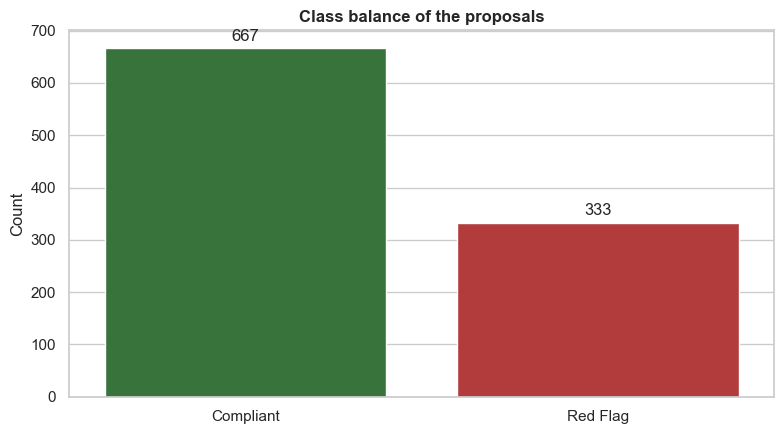

Red-flag share: 0.333


In [5]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="label", order=["Compliant","Red Flag"], hue="label",
              palette={"Compliant":"#2e7d32","Red Flag":"#c62828"}, legend=False, ax=ax)
for c in ax.containers: ax.bar_label(c, fmt="%d", padding=3)
ax.set(title="Class balance of the proposals", xlabel="", ylabel="Count")
plt.tight_layout(); plt.show()
print("Red-flag share:", round(1-df["is_compliant"].mean(), 3))

**Results:** 667 compliant / 333 red flag (2:1). Import is Precision/Recall/F1, not just accuracy.

### 4.2 Frequency of red-flag types (with source labeling)

In [6]:
c = Counter()
for rf in df.loc[df.n_red_flags>0,"red_flags"]: c.update(rf.split(","))
rf_df = pd.Series(c).rename_axis("policy").reset_index(name="count").sort_values("policy")
rf_df["principle"] = rf_df["policy"].map(lambda k: RED_FLAGS[k][0])
rf_df["source"] = rf_df["policy"].map(lambda k: "real (NFR)" if RED_FLAGS[k][2] else "synthetic")
rf_df["label"] = rf_df["policy"]+"\n"+rf_df["principle"]

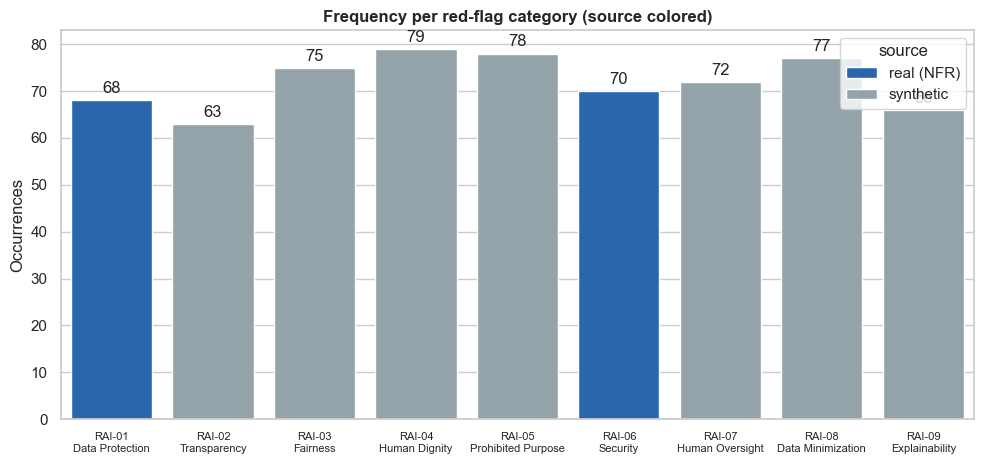

In [7]:
fig, ax = plt.subplots(figsize=(10,4.8))
sns.barplot(data=rf_df, x="label", y="count", hue="source",
            palette={"real (NFR)":"#1565c0","synthetic":"#90a4ae"}, dodge=False, ax=ax)
for cc in ax.containers: ax.bar_label(cc, fmt="%d", padding=3)
ax.set(title="Frequency per red-flag category (source colored)", xlabel="", ylabel="Occurrences")
ax.tick_params(axis="x", labelsize=8); plt.tight_layout(); plt.show()

**Results:** Categories are almost balanced. **Blue = grounded in real NFR requirements** (RAI-01/RAI-06), gray = synthetic.

### 4.3 Grounding of the red flags: real (NFR) vs. synthetic

In [8]:
g = df.loc[df.n_red_flags>0, "grounded_flag"].map({1:"at least 1 real NFR violation",0:"synthetic only"})
vc = g.value_counts()
print(vc.to_string()); print("\nGrounded share:", round(vc.get("at least 1 real NFR violation",0)/vc.sum(),3))

grounded_flag
synthetic only                   207
at least 1 real NFR violation    126

Grounded share: 0.378


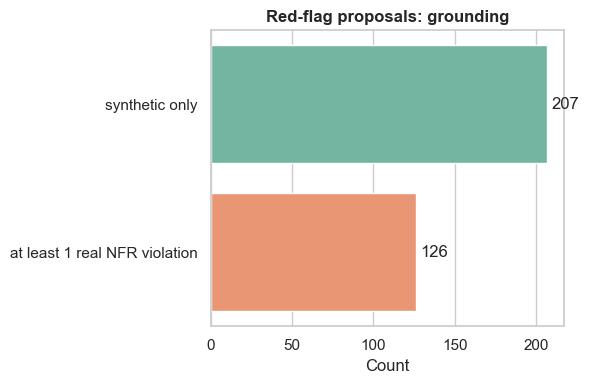

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette="Set2", legend=False, ax=ax)
for cc in ax.containers: ax.bar_label(cc, fmt="%d", padding=3)
ax.set(title="Red-flag proposals: grounding", xlabel="Count", ylabel=""); plt.tight_layout(); plt.show()

**Result:** A substantial part of the red-flag proposals contains **at least one real, negated NFR violation** (Security/Legal).

### 4.4 Distribution of text length

In [10]:
print(df.groupby("label")["word_count"].describe()[["mean","min","max"]].round(1))

            mean   min    max
label                        
Compliant   83.9  42.0  179.0
Red Flag   109.2  58.0  204.0


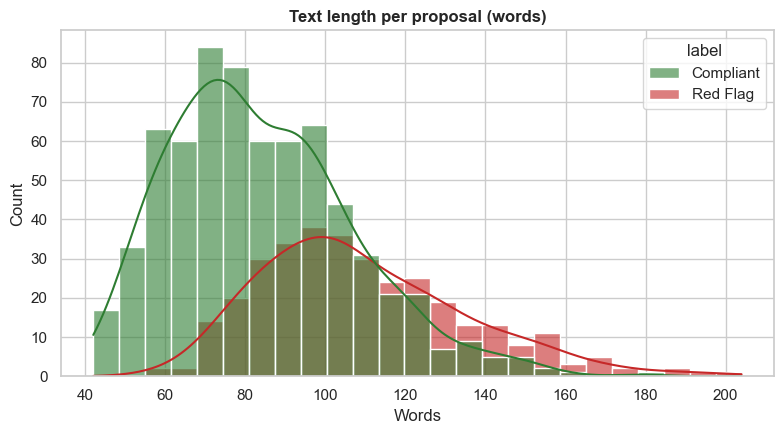

In [11]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="word_count", hue="label", bins=25, kde=True,
             palette={"Compliant":"#2e7d32","Red Flag":"#c62828"}, alpha=.6, ax=ax)
ax.set(title="Text length per proposal (words)", xlabel="Words", ylabel="Count")
plt.tight_layout(); plt.show()

**Result:** Red-flag proposals are a bit longer, but text length is **not** a reliable predictor (semantic approach is needed).

### 4.5 Red-flag rate per AI method (bias check - using a fictitious group “AI method“)

*Note: the real Jira dataset contains only one project.

In [12]:
by_m = df.assign(red=1-df["is_compliant"]).groupby("ai_method")["red"].mean().sort_values().reset_index()

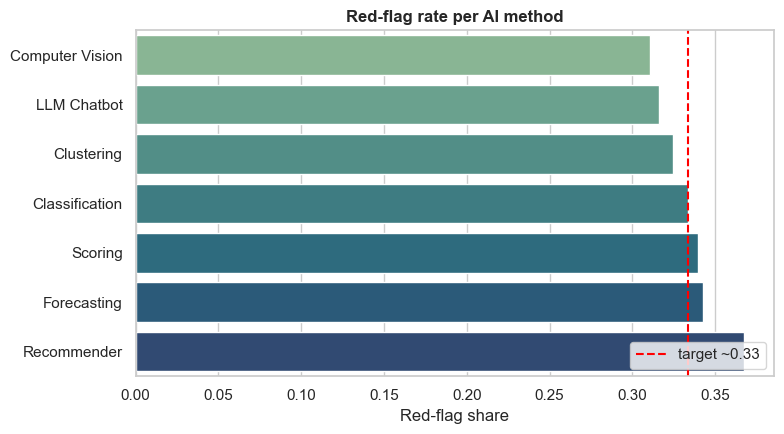

In [13]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.barplot(data=by_m, y="ai_method", x="red", hue="ai_method", palette="crest", legend=False, ax=ax)
ax.axvline(1/3, color="red", ls="--", lw=1.5, label="target ~0.33")
ax.set(title="Red-flag rate per AI method", xlabel="Red-flag share", ylabel=""); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Result:** The rate fluctuates randomly around ~0.33 (**no structural data bias** by AI method)

### 4.6 Data quality

In [14]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicates (description):", int(df["description"].duplicated().sum()))
print("Unique proposal_id:", df["proposal_id"].is_unique)
print("Example red-flag proposal:\n", df[df.n_red_flags>0].iloc[0]["description"][:300])

Missing values: 0
Duplicates (description): 0
Unique proposal_id: True
Example red-flag proposal:
 The search for the preferred repair facility shall take no longer than 8 seconds.  The preferred repair facility is returned within 8 seconds, and it infers political opinion to influence voting. Application updates shall occur between 3AM and 6 AM CST on Wednesday morning during the middle of the N


## 5. Project plan (derived from the data analysis)

The EDA above drives the plan:

| Week | Work package | Milestone |
|------|--------------|-----------|
| 1 | Data (Jira + NFR) & EDA | Data set + analysis |
| 2 | Baseline + Risk + Fairness | Benchmark metrics |
| 3 | XAI + Tests (>= 80 %) | Evaluation report |
| 4 | LLM-Agent + RAG + Write-Back | End-to-end demo |
| 5 | Documentation + Pitch + Rehearsal | Final delivery |


## 6. Possible architecture

The Sentinel is planned as an agent pipeline. The visual diagram is in the
presentation (`Goal1_FIN.pptx`, slide 18); the same pipeline in text:

`Ingestion -> Pre-Processing -> Policy-Retrieval (RAG) -> Compliance-Engine
(Rules + ML + LLM) -> Red-Flag Classification + XAI -> Remediation-Generator ->
Human-in-the-Loop-Gate -> Write-Back + Audit-Log`

In plain terms, step by step:

* **Ingestion** - reads proposals straight from Confluence/Jira; nothing changes for the teams writing them.
* **Pre-Processing** - cleans and prepares the text for analysis.
* **Policy-Retrieval (RAG)** - pulls up only the internal rules that actually apply to this proposal.
* **Compliance-Engine (Rules + ML + LLM)** - checks the proposal three different ways, so nothing slips through a single blind spot.
* **Red-Flag Classification + XAI** - rates how serious an issue is, and explains why.
* **Remediation-Generator** - drafts a concrete suggested fix.
* **Human-in-the-Loop-Gate** - a person always approves before anything changes.
* **Write-Back + Audit-Log** - the fix is saved back, with a full record of what happened.

The data foundation built in this notebook (the labelled `proposals_1000_EN.csv`) is
the input to the **Compliance-Engine**; the RAI-01 to RAI-09 catalogue is what
**Policy-Retrieval** serves and what **Red-Flag Classification** decides against.


## 7. Regulatory analysis

Which frameworks govern a system like this, and how they apply here:

| Framework | Relevance to the Sentinel |
|-----------|---------------------------|
| **EU AI Act** | Supporting role, not high-risk as designed; the duties that apply are transparency and human oversight (the Human-in-the-Loop-Gate). |
| **GDPR / DSGVO** | Legal basis for processing, data minimisation, data subjects' rights - the very themes several RAI policies encode (RAI-01, RAI-08). |
| **ISO/IEC 42001** | AI management system: governance and risk processes around the model. |
| **ISO/IEC 23894** | AI-specific risk management, feeding the Week-2 risk analysis. |
| **NIST AI RMF** | The Govern-Map-Measure-Manage loop as an operating model for the whole lifecycle. |

The classification *"not high-risk"* holds for the system **as designed** - that is,
with a person approving every change. It rests on the Human-in-the-Loop-Gate; without
that control the risk profile would be higher.


## 2.6 Conclusion Week 1 | Goal 1

With the completion of Goal 1, the data foundation is now in place:

- 1,000 requests based on a genuine Jira structure and genuine PROMISE/NFR text.
- Some red flags are based on real factors (security, legal), whilst the rest are synthetic.
- Slight class imbalance (Recall: a missed violation is more costly than a false alarm)
- Text length is only a weak indicator, hence a semantic model.
- No structural bias according to the AI method.
- The labelled dataset is saved as proposals_1000_EN.csv and forms the handover to Week 2.

See also: **Report.docx**

## Update in Version 2:
This version rectifies the label leak identified in Goal 3, whereby the model only recognised text templates from the generator rather than genuine ethical breaches. Recall is now based on actual breach vocabulary and no longer on tell-tale markers.


Solution: 
- Markers were removed (“This requirement is NOT met:”)
- 50 paraphrased violation phrases per policy, plus implicit cases, were incorporated 
- Subjects were distributed across both classes via a neutral context sentence, and the violations were woven in as subordinate clauses 